# 7.3 기타 필터링
선형 공간 필터링과 비선형 공간 필터링으로 나누어지고 지금까지 한 것은 선형 공간 필터링이다 이번에는 비선형 공간 필터링을 배워보겠다.  

## 7.3.1 최댓값/최솟값 필터링
마스크로 씌워진 영역의 입력 화소들로 최댓값과 최솟값을 출력 화소로 결정하는 방법이다.  
최댓값 필터링은 가장 큰 값인 밝은 색으로만 구성되어 돌출되는 어두운 값을 제거할 수 있고 전체적으로 밝은 영상이 되고 최솟값 필터링은 그 반대이다.  
최댓값 필터링은 밝은 임펄스 잡음이 강조되고 최솟값 필터링은 그 반대인데 이는 높은 대조를 가진 영상에서 특징을 확대시키기 위한 기법으로 사용 될 수 있다.  

In [1]:
import numpy as np, cv2
import matplotlib.pyplot as plt

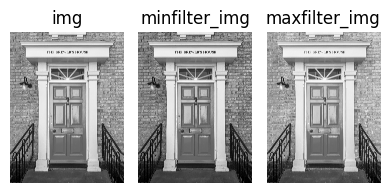

In [3]:
def minmax_filter(img, ksize, mode):
    rows, cols = img.shape[:2]
    dst = np.zeros((rows, cols), np.uint8)
    center = ksize // 2

    for i in range(center, rows - center):
        for j in range(center, cols - center):
            y1, y2 = i - center, i + center + 1
            x1, x2 = j - center, j + center + 1
            mask = img[y1:y2, x1:x2]
            dst[i, j] = cv2.minMaxLoc(mask)[mode]

    return dst

img = cv2.imread("../images/door.jpg", cv2.IMREAD_GRAYSCALE)

minfilter_img = minmax_filter(img, 3, 0)
maxfilter_img = minmax_filter(img, 3, 1)

titles = ['img', 'minfilter_img', 'maxfilter_img']

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(4, 12))

for ax, title in zip(axs.flat, titles):
    ax.imshow(eval(title), cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()


## 7.3.2 평균값 필터링
평균을 구하여 출력 화소로 지정하는 방법이다. 블러링 마스크(7.1.2)를 적용한 것과 같다.

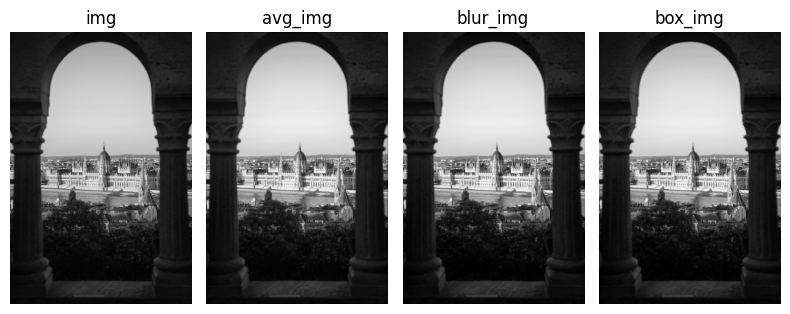

In [9]:
def avg_filter(img, ksize):
    rows, cols = img.shape[:2]
    dst = np.zeros((rows, cols), np.uint8)
    center = ksize // 2

    for i in range(center, rows - center):
        for j in range(center, cols - center):
            y1, y2 = i - center, i + center + 1
            x1, x2 = j - center, j + center + 1
            if y1 < 0 or y2 > rows or x1 < 0 or x2 > cols:
                dst[i, j] = img[i, j]
            else:
                mask = img[y1:y2, x1:x2]
                dst[i, j] = cv2.mean(mask)[0]

    return dst

img = cv2.imread("../images/castle.jpg", cv2.IMREAD_GRAYSCALE)

avg_img = avg_filter(img, 5)
blur_img = cv2.blur(img, (5, 5), anchor=(-1, -1), borderType=cv2.BORDER_REFLECT)
box_img = cv2.boxFilter(img, ddepth=-1, ksize=(5, 5))

titles = ['img', 'avg_img', 'blur_img', 'box_img']
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(8, 20))

for ax, title in zip(axs.flat, titles):
    ax.imshow(eval(title), cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 7.3.3 미디언 필터링
중간값을 출력 화소로 정하는 것인데 일정 영역에서 다른 화소들과 밝기 차이가 심하게 나는 화소들은 임펄스 잡음, 소금-후추 잡음일 가능성이 높다 그래서 심하게 차이나는 원소는 최소/최대 값이 되고 미디언 필터링에 의해서 중간값 이외에는 제거되고 저 두 잡음을 잘 잡는다.  
평균값 필터링에 비하면 블러링 현상이 적다.  
하지만 마스크 크기가 커지면 정렬 알고리즘 수행으로 수행 시간이 커진다. 
미디언 필터링은 명암도 영상에서 효과적이며 rgb 조합에 의해서 맞지 않을 수 있어 미디언 필터링은 오히려 잡음이 많아질 수도 있다.

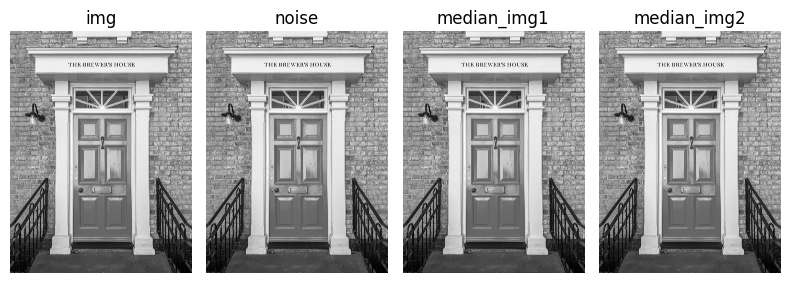

In [3]:
def median_filter(img, ksize):
    rows, cols = img.shape[:2]
    dst = np.zeros((rows, cols), np.uint8)
    center = ksize // 2

    for i in range(center, rows - center):
        for j in range(center, cols - center):
            y1, y2 = i - center, i + center + 1
            x1, x2 = j - center, j + center + 1
            mask = img[y1:y2, x1:x2]

            dst[i, j] = np.median(mask)

    return dst

def salt_pepper_noise(img, n):
    h, w = img.shape[:2]
    x, y = np.random.randint(0, w, n), np.random.randint(0, h, n)
    noise = img.copy()
    for (x, y) in zip(x, y):
        noise[y, x] = 0 if np.random.rand() < 0.5 else 255

    return noise

img = cv2.imread("../images/door.jpg", cv2.IMREAD_GRAYSCALE)

noise = salt_pepper_noise(img, 500)
median_img1 = median_filter(noise, 5)
median_img2 = cv2.medianBlur(noise, 5)

titles = ['img', 'noise', 'median_img1', 'median_img2']
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(8, 20))

for ax, title in zip(axs.flat, titles):
    ax.imshow(eval(title), cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 7.3.4 가우시안 스무딩 필터링
스무딩은 영상의 세세한 부분을 회선을 통해서 부드럽게 하는 기법으로 블러딩이랑 같은 의미이다.  
가우시안 필터링은 가우시안 분포를 마스크의 계수로 사용하여 회선을 수행하는 것을 말한다. 가우시안 분포는 평균에서 가장 큰 수치를 가지며 평균을 중심으로 좌우 대칭 형태이다. 그리고 양 끝으로 갈 수록 급격하게 수치가 낮아진다. 그리고 평균과 표준편차에 의해 그래프가 변하는데 표준편차가 커지면 폭이 넓어진다.  
가우스 분포를 회선 마스크로 적용하려면 정규분포식을 2차원 행렬로 구성하면 된다. 그리고 마스크 계수를 1로 하여 밝기를 유지시키고 표준 편차를 변경하여 계수의 구성을 조정할 수 있다.  
표준편차가 크면 평균의 높이는 낮아지고 폭이 넓어진다. 그래서 결과 영상에 중심 화소와 비슷한 비중으로 주변 화소가 반영되기 때문에 흐림의 정도가 심해진다.

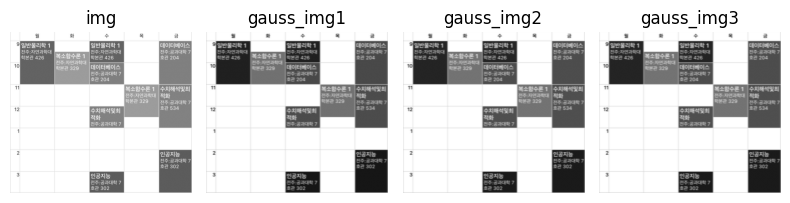

In [12]:
def getGaussianMask(ksize, sigmaX, sigmaY):
    sigma = .3 * ((np.array(ksize) - 1.0) * .5 - 1.0) + .8
    if sigmaX <= 0: sigmaX = sigma[0]
    if sigmaY <= 0: sigmaY = sigma[1]

    u = np.array(ksize) // 2
    x = np.arange(-u[0], u[0] + 1, 1)
    y = np.arange(-u[1], u[1] + 1, 1)
    x, y = np.meshgrid(x, y)

    ratio = 1 / (sigmaX * sigmaX * 2 * np.pi)
    v1 = x ** 2 / (2 * sigmaX ** 2)
    v2 = y ** 2 / (2 * sigmaY ** 2)
    mask = ratio * np.exp(-(v1 + v2))
    return mask / np.sum(mask)

img = cv2.imread("../images/timetable.jpg", cv2.IMREAD_GRAYSCALE)

ksize = (17, 5)
gaussian_2d = getGaussianMask(ksize, 0, 0)
gaussian_1dX = cv2.getGaussianKernel(ksize[0], 0, cv2.CV_32F)
gaussian_1dY = cv2.getGaussianKernel(ksize[1], 0, cv2.CV_32F)

gauss_img1 = cv2.filter2D(img, -1, gaussian_2d)
gauss_img2 = cv2.GaussianBlur(img, ksize, 0)
gauss_img3 = cv2.sepFilter2D(img, -1, gaussian_1dX, gaussian_1dY)


titles = ['img', 'gauss_img1', 'gauss_img2', 'gauss_img3']
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(8, 20))

for ax, title in zip(axs.flat, titles):
    ax.imshow(eval(title), cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()